<a href="https://colab.research.google.com/github/cristiangaymartin/tfm-estados-mercado/blob/main/notebooks/03_tendencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · Clasificación de tendencia (XGBoost)

Predicción supervisada del régimen futuro del S&P 500 mediante XGBoost.
Objetivo inicial: clasificación binaria del deterioro (¿estará el mercado en
corrección o crisis dentro de 20 días?). Horizonte de un mes bursátil.
Tercera etapa, tras la detección de regímenes de `02`.

In [1]:
%pip install hmmlearn --quiet
%pip install xgboost --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

In [3]:
from google.colab import drive
drive.mount('/content/drive')
RUTA_DATOS = "/content/drive/MyDrive/TFM/data"
RUTA_DOCS  = "/content/drive/MyDrive/TFM/docs"

sp = pd.read_csv(f"{RUTA_DATOS}/mercado_SP500.csv", index_col=0, parse_dates=True)
print("S&P cargado:", sp.shape, "| desde", sp.index.min().date())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
S&P cargado: (9213, 3) | desde 1990-01-02


In [4]:
def detectar_regimenes(df, n_estados=4, random_state=42):
    """Detecta regímenes de mercado con HMM. Devuelve datos con columnas 'estado' y 'regimen'."""
    datos = df[["ret_log", "vol_21d"]].dropna().copy()
    scaler = StandardScaler()
    X = scaler.fit_transform(datos)
    modelo = hmm.GaussianHMM(n_components=n_estados, covariance_type="full",
                             n_iter=1000, random_state=random_state)
    modelo.fit(X)
    datos["estado"] = modelo.predict(X)
    nombres = ["Calma alcista", "Normal", "Corrección", "Crisis"][:n_estados]
    vol_por_estado = datos.groupby("estado")["vol_21d"].mean().sort_values()
    mapeo = {est: nom for est, nom in zip(vol_por_estado.index, nombres)}
    datos["regimen"] = datos["estado"].map(mapeo)
    return datos, modelo

sp_reg, _ = detectar_regimenes(sp)
print("Regímenes recalculados:", sp_reg["regimen"].value_counts().to_dict())

Regímenes recalculados: {'Calma alcista': 3763, 'Normal': 2661, 'Corrección': 1897, 'Crisis': 871}


In [5]:
HORIZONTE = 20   # días de mercado (~1 mes bursátil)

# Definimos qué regímenes cuentan como "estrés"
regimenes_estres = ["Corrección", "Crisis"]

# Partimos de los regímenes del S&P
df = sp_reg.copy()

# El régimen que habrá dentro de HORIZONTE días: desplazamos la columna hacia atrás
df["regimen_futuro"] = df["regimen"].shift(-HORIZONTE)

# Objetivo binario: 1 si el régimen futuro es de estrés, 0 si no
df["objetivo"] = df["regimen_futuro"].isin(regimenes_estres).astype(int)

# Los últimos HORIZONTE días no tienen futuro conocido: quedan como NaN y los marcamos
df.loc[df["regimen_futuro"].isna(), "objetivo"] = np.nan

print("Distribución del objetivo:")
print(df["objetivo"].value_counts(dropna=False))
print(f"\n% de días con estrés futuro: {100*df['objetivo'].mean():.1f}%")

Distribución del objetivo:
objetivo
0.0    6404
1.0    2768
NaN      20
Name: count, dtype: int64

% de días con estrés futuro: 30.2%


In [6]:
# Partimos del dataframe que ya tiene regímenes y objetivo
# Todas las features miran SOLO hacia atrás (información disponible "hoy")

# --- Familia 1: rendimiento reciente (momentum) ---
df["ret_5d"]  = df["ret_log"].rolling(5).sum()    # rendimiento acumulado última semana
df["ret_20d"] = df["ret_log"].rolling(20).sum()   # rendimiento acumulado último mes

# --- Familia 2: volatilidad reciente (nivel de agitación actual) ---
df["vol_5d"]  = df["ret_log"].rolling(5).std()    # volatilidad muy reciente
# vol_21d ya existe (volatilidad del último mes)

# --- Familia 3: tendencia de la volatilidad (¿se está acelerando la agitación?) ---
df["vol_cambio"] = df["vol_21d"] - df["vol_21d"].shift(10)  # cambio de vol en 10 días
# Traemos el precio de cierre desde el S&P original
df["Close"] = sp["Close"]

# --- Familia 4: posición respecto a medias móviles ---
df["media_50"]  = df["Close"].rolling(50).mean()
df["dist_media50"] = (df["Close"] - df["media_50"]) / df["media_50"]  # distancia % a la media

# --- Familia 5: el régimen actual (¡información valiosísima!) ---
nivel = {"Calma alcista": 0, "Normal": 1, "Corrección": 2, "Crisis": 3}
df["regimen_actual"] = df["regimen"].map(nivel)

# Lista de las variables predictoras
features = ["ret_5d", "ret_20d", "vol_5d", "vol_21d", "vol_cambio",
            "dist_media50", "regimen_actual"]

print("Variables predictoras creadas:", features)
print("\nComprobación de que todas miran hacia atrás (primeras filas con NaN esperados):")
print(df[features].head(3))
print("\nNaN por variable:")
print(df[features].isna().sum())

Variables predictoras creadas: ['ret_5d', 'ret_20d', 'vol_5d', 'vol_21d', 'vol_cambio', 'dist_media50', 'regimen_actual']

Comprobación de que todas miran hacia atrás (primeras filas con NaN esperados):
            ret_5d  ret_20d  vol_5d   vol_21d  vol_cambio  dist_media50  \
Date                                                                      
1990-01-31     NaN      NaN     NaN  0.010562         NaN           NaN   
1990-02-01     NaN      NaN     NaN  0.010582         NaN           NaN   
1990-02-02     NaN      NaN     NaN  0.010773         NaN           NaN   

            regimen_actual  
Date                        
1990-01-31               1  
1990-02-01               1  
1990-02-02               1  

NaN por variable:
ret_5d             4
ret_20d           19
vol_5d             4
vol_21d            0
vol_cambio        10
dist_media50      49
regimen_actual     0
dtype: int64


In [7]:
# 1. Nos quedamos con las filas completas (sin NaN en features ni en objetivo)
df_modelo = df.dropna(subset=features + ["objetivo"]).copy()
print("Filas utilizables:", len(df_modelo))
print("Rango:", df_modelo.index.min().date(), "→", df_modelo.index.max().date())

# 2. Partición temporal: 80% más antiguo para entrenar, 20% más reciente para test
punto_corte = int(len(df_modelo) * 0.80)
fecha_corte = df_modelo.index[punto_corte]

train = df_modelo.iloc[:punto_corte]
test  = df_modelo.iloc[punto_corte:]

print(f"\nFecha de corte: {fecha_corte.date()}")
print(f"Entrenamiento: {len(train)} días ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test:          {len(test)} días ({test.index.min().date()} → {test.index.max().date()})")

# 3. Separamos variables (X) y objetivo (y) en cada conjunto
X_train, y_train = train[features], train["objetivo"]
X_test,  y_test  = test[features],  test["objetivo"]

# 4. Comprobamos el balance del objetivo en cada conjunto
print(f"\n% estrés en entrenamiento: {100*y_train.mean():.1f}%")
print(f"% estrés en test:          {100*y_test.mean():.1f}%")

Filas utilizables: 9123
Rango: 1990-04-11 → 2026-07-06

Fecha de corte: 2019-04-01
Entrenamiento: 7298 días (1990-04-11 → 2019-03-29)
Test:          1825 días (2019-04-01 → 2026-07-06)

% estrés en entrenamiento: 30.0%
% estrés en test:          31.9%


In [8]:
# Peso para compensar el desbalanceo 70/30 (da más importancia a la clase minoritaria "estrés")
peso = (y_train == 0).sum() / (y_train == 1).sum()

modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=peso,   # compensa que el estrés es minoritario
    random_state=42,
    eval_metric="logloss"
)

modelo_xgb.fit(X_train, y_train)

# Predicciones sobre el test (el "futuro no visto")
y_pred = modelo_xgb.predict(X_test)
y_prob = modelo_xgb.predict_proba(X_test)[:, 1]   # probabilidad de estrés

print("Modelo entrenado y predicciones generadas sobre el test.")

Modelo entrenado y predicciones generadas sobre el test.


In [9]:
# 1. Informe completo de métricas
print("=== Informe de clasificación (test) ===")
print(classification_report(y_test, y_pred, target_names=["Tranquilo", "Estrés"]))

# 2. Matriz de confusión
print("=== Matriz de confusión ===")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm,
    index=["Real: Tranquilo", "Real: Estrés"],
    columns=["Pred: Tranquilo", "Pred: Estrés"]))

# 3. AUC: capacidad de discriminación global (usa las probabilidades)
auc = roc_auc_score(y_test, y_prob)
print(f"\nAUC (área bajo la curva ROC): {auc:.3f}")

# 4. Comparación con el modelo tramposo "siempre tranquilo"
baseline = accuracy_score(y_test, [0]*len(y_test))
print(f"\nExactitud del modelo: {accuracy_score(y_test, y_pred):.3f}")
print(f"Exactitud de 'predecir siempre tranquilo': {baseline:.3f}")

=== Informe de clasificación (test) ===
              precision    recall  f1-score   support

   Tranquilo       0.87      0.84      0.86      1243
      Estrés       0.69      0.73      0.70       582

    accuracy                           0.81      1825
   macro avg       0.78      0.78      0.78      1825
weighted avg       0.81      0.81      0.81      1825

=== Matriz de confusión ===
                 Pred: Tranquilo  Pred: Estrés
Real: Tranquilo             1049           194
Real: Estrés                 160           422

AUC (área bajo la curva ROC): 0.846

Exactitud del modelo: 0.806
Exactitud de 'predecir siempre tranquilo': 0.681


Importancia de cada variable (por 'gain'):

regimen_actual    471.1
vol_5d             24.3
vol_21d            19.2
ret_5d             16.1
dist_media50       14.9
ret_20d            13.9
vol_cambio         11.8
dtype: float64


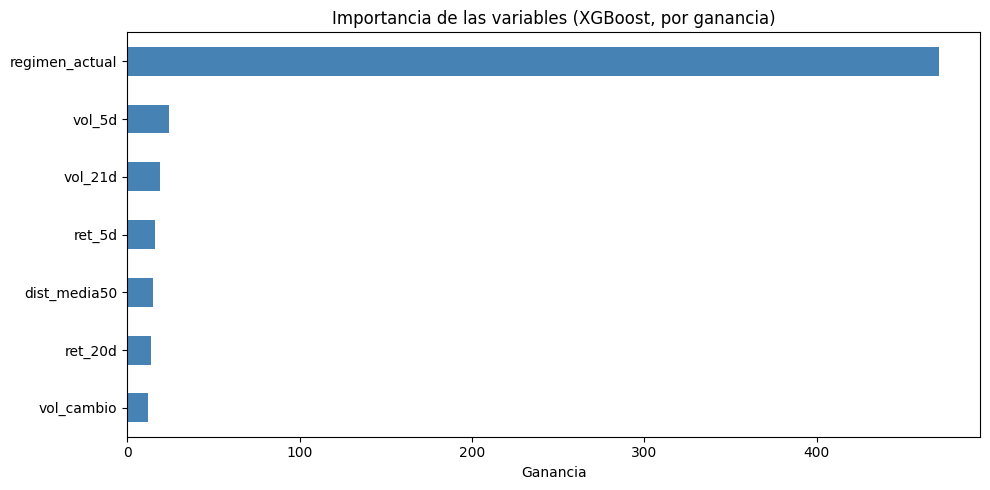

In [10]:
# Importancia por "gain" (la más informativa)
importancia = pd.Series(
    modelo_xgb.get_booster().get_score(importance_type="gain")
).sort_values(ascending=False)

# Los nombres salen como 'f0', 'f1'... los traducimos a los nombres reales
mapa_nombres = {f"f{i}": nombre for i, nombre in enumerate(features)}
importancia.index = [mapa_nombres.get(i, i) for i in importancia.index]

print("Importancia de cada variable (por 'gain'):\n")
print(importancia.round(1))

# Gráfico de barras
fig, ax = plt.subplots(figsize=(10, 5))
importancia.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Importancia de las variables (XGBoost, por ganancia)")
ax.set_xlabel("Ganancia")
plt.tight_layout()
plt.savefig(f"{RUTA_DOCS}/importancia_variables.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Features SIN el régimen del HMM
features_sin_regimen = [f for f in features if f != "regimen_actual"]
print("Variables usadas (sin régimen):", features_sin_regimen)

# Reentrenamos el mismo modelo, solo cambian las variables
modelo_sin_reg = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=peso, random_state=42, eval_metric="logloss"
)
modelo_sin_reg.fit(X_train[features_sin_regimen], y_train)

# Evaluamos sobre el mismo test
y_prob_sin = modelo_sin_reg.predict_proba(X_test[features_sin_regimen])[:, 1]
auc_sin = roc_auc_score(y_test, y_prob_sin)

# Comparación
print(f"\n{'='*40}")
print(f"AUC modelo COMPLETO (con régimen):  {auc:.3f}")
print(f"AUC modelo SIN régimen del HMM:     {auc_sin:.3f}")
print(f"Caída de AUC al quitar el régimen:  {auc - auc_sin:.3f}")
print(f"{'='*40}")

Variables usadas (sin régimen): ['ret_5d', 'ret_20d', 'vol_5d', 'vol_21d', 'vol_cambio', 'dist_media50']

AUC modelo COMPLETO (con régimen):  0.846
AUC modelo SIN régimen del HMM:     0.840
Caída de AUC al quitar el régimen:  0.006


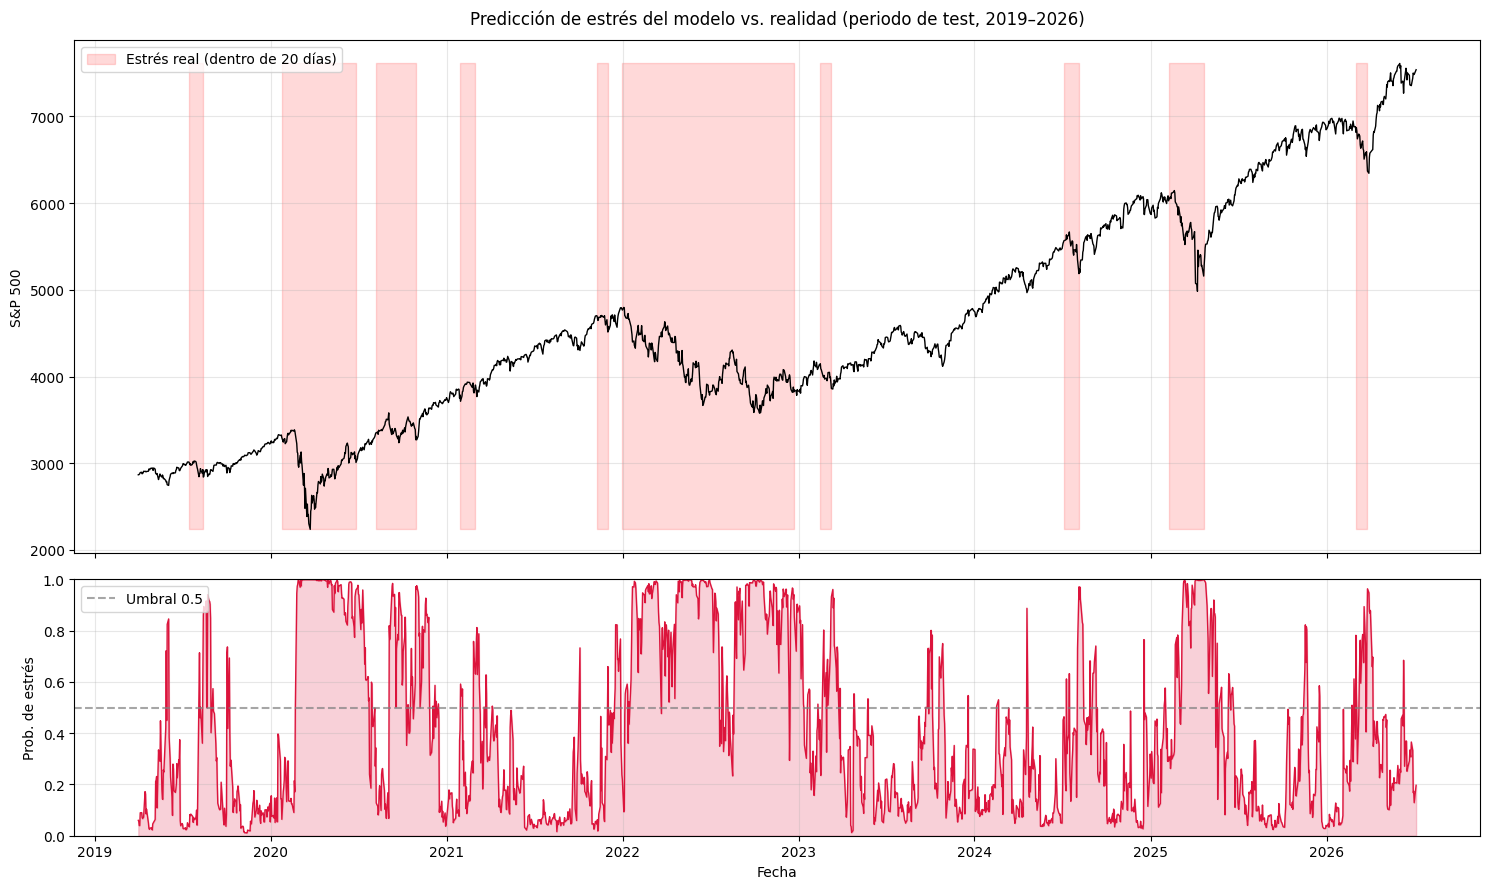

In [12]:
# Preparamos un dataframe con el test: precio, probabilidad predicha y realidad
viz = test.copy()
viz["prob_estres"] = y_prob        # probabilidad de estrés que predijo el modelo
viz["Close"] = sp["Close"]         # traemos el precio

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

# --- Panel superior: precio del S&P, coloreado según estrés REAL ---
ax1.plot(viz.index, viz["Close"], color="black", linewidth=1, zorder=3)
ax1.fill_between(viz.index, viz["Close"].min(), viz["Close"].max(),
                 where=(viz["objetivo"] == 1), color="red", alpha=0.15,
                 label="Estrés real (dentro de 20 días)")
ax1.set_ylabel("S&P 500")
ax1.set_title("Predicción de estrés del modelo vs. realidad (periodo de test, 2019–2026)", pad=12)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# --- Panel inferior: probabilidad de estrés que predice el modelo ---
ax2.plot(viz.index, viz["prob_estres"], color="crimson", linewidth=1)
ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.7, label="Umbral 0.5")
ax2.fill_between(viz.index, 0, viz["prob_estres"], color="crimson", alpha=0.2)
ax2.set_ylabel("Prob. de estrés")
ax2.set_xlabel("Fecha")
ax2.set_ylim(0, 1)
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RUTA_DOCS}/predicciones_temporales.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Añadimos al dataframe de test la predicción y clasificamos cada día
viz["pred"] = y_pred

def tipo_resultado(fila):
    real, pred = fila["objetivo"], fila["pred"]
    if real == 1 and pred == 1: return "Acierto estrés"
    if real == 0 and pred == 0: return "Acierto tranquilo"
    if real == 1 and pred == 0: return "FALLO: estrés no detectado"   # falso negativo
    if real == 0 and pred == 1: return "FALLO: falsa alarma"          # falso positivo

viz["resultado"] = viz.apply(tipo_resultado, axis=1)

print("Reparto de resultados en el test:")
print(viz["resultado"].value_counts())

Reparto de resultados en el test:
resultado
Acierto tranquilo             1049
Acierto estrés                 422
FALLO: falsa alarma            194
FALLO: estrés no detectado     160
Name: count, dtype: int64


In [14]:
# Nos quedamos solo con los falsos negativos (estrés que se escapó)
falsos_neg = viz[viz["resultado"] == "FALLO: estrés no detectado"]

print("Falsos negativos (estrés no anticipado) por año:")
print(falsos_neg.index.year.value_counts().sort_index())

print(f"\nTotal falsos negativos: {len(falsos_neg)}")
print(f"Rango de fechas de los falsos negativos:")
print(f"  Concentración principal: {falsos_neg.index.min().date()} → {falsos_neg.index.max().date()}")

Falsos negativos (estrés no anticipado) por año:
Date
2019    17
2020    46
2021    35
2022    25
2023     4
2024    18
2025    11
2026     4
Name: count, dtype: int64

Total falsos negativos: 160
Rango de fechas de los falsos negativos:
  Concentración principal: 2019-07-16 → 2026-03-24


In [15]:
# Agrupamos falsos negativos por mes
por_mes = falsos_neg.groupby(falsos_neg.index.to_period("M")).size().sort_values(ascending=False)
print("Los 8 meses con más estrés no anticipado:")
print(por_mes.head(8))

Los 8 meses con más estrés no anticipado:
Date
2020-08    18
2024-07    17
2021-11    16
2021-02    15
2020-02    14
2022-08    13
2019-07    12
2025-02     9
Freq: M, dtype: int64


In [16]:
# Nuevo objetivo: el nivel de régimen futuro (0=calma, 1=normal, 2=corrección, 3=crisis)
nivel = {"Calma alcista": 0, "Normal": 1, "Corrección": 2, "Crisis": 3}
df["objetivo_4c"] = df["regimen_futuro"].map(nivel)

# Rehacemos la partición temporal con el nuevo objetivo (mismo corte que antes)
df_modelo_4c = df.dropna(subset=features + ["objetivo_4c"]).copy()
train_4c = df_modelo_4c.iloc[:punto_corte]
test_4c  = df_modelo_4c.iloc[punto_corte:]

X_train_4c, y_train_4c = train_4c[features], train_4c["objetivo_4c"].astype(int)
X_test_4c,  y_test_4c  = test_4c[features],  test_4c["objetivo_4c"].astype(int)

print("Distribución del objetivo (entrenamiento):")
print(y_train_4c.value_counts().sort_index())
print("\n0=Calma, 1=Normal, 2=Corrección, 3=Crisis")

Distribución del objetivo (entrenamiento):
objetivo_4c
0    3127
1    1985
2    1515
3     671
Name: count, dtype: int64

0=Calma, 1=Normal, 2=Corrección, 3=Crisis


In [17]:
# XGBoost multiclase (detecta solo que hay 4 clases)
modelo_4c = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="multi:softprob", num_class=4,
    random_state=42, eval_metric="mlogloss"
)
modelo_4c.fit(X_train_4c, y_train_4c)

y_pred_4c = modelo_4c.predict(X_test_4c)
print("Modelo de 4 clases entrenado.")

Modelo de 4 clases entrenado.


In [18]:
nombres_clases = ["Calma", "Normal", "Corrección", "Crisis"]

print("=== Informe de clasificación (4 clases) ===")
print(classification_report(y_test_4c, y_pred_4c, target_names=nombres_clases))

print("=== Matriz de confusión ===")
cm4 = confusion_matrix(y_test_4c, y_pred_4c)
print(pd.DataFrame(cm4,
    index=[f"Real: {n}" for n in nombres_clases],
    columns=[f"Pred: {n}" for n in nombres_clases]))

=== Informe de clasificación (4 clases) ===
              precision    recall  f1-score   support

       Calma       0.48      0.70      0.57       603
      Normal       0.42      0.29      0.34       640
  Corrección       0.40      0.40      0.40       382
      Crisis       0.56      0.34      0.42       200

    accuracy                           0.45      1825
   macro avg       0.46      0.43      0.43      1825
weighted avg       0.45      0.45      0.44      1825

=== Matriz de confusión ===
                  Pred: Calma  Pred: Normal  Pred: Corrección  Pred: Crisis
Real: Calma               421           146                36             0
Real: Normal              359           186                83            12
Real: Corrección           85           103               153            41
Real: Crisis               15            12               106            67


In [19]:
# Peso inversamente proporcional a la frecuencia de cada clase
pesos_muestra = compute_sample_weight(class_weight="balanced", y=y_train_4c)

# Mismo modelo, ahora con pesos por muestra
modelo_4c_pond = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    objective="multi:softprob", num_class=4,
    random_state=42, eval_metric="mlogloss"
)
modelo_4c_pond.fit(X_train_4c, y_train_4c, sample_weight=pesos_muestra)

y_pred_4c_pond = modelo_4c_pond.predict(X_test_4c)
print("Modelo ponderado entrenado.")

Modelo ponderado entrenado.


In [20]:
print("=== SIN ponderar (modelo original) ===")
print(classification_report(y_test_4c, y_pred_4c, target_names=nombres_clases))

print("\n=== CON ponderación de clases ===")
print(classification_report(y_test_4c, y_pred_4c_pond, target_names=nombres_clases))

print("=== Matriz de confusión (ponderado) ===")
cm4p = confusion_matrix(y_test_4c, y_pred_4c_pond)
print(pd.DataFrame(cm4p,
    index=[f"Real: {n}" for n in nombres_clases],
    columns=[f"Pred: {n}" for n in nombres_clases]))

=== SIN ponderar (modelo original) ===
              precision    recall  f1-score   support

       Calma       0.48      0.70      0.57       603
      Normal       0.42      0.29      0.34       640
  Corrección       0.40      0.40      0.40       382
      Crisis       0.56      0.34      0.42       200

    accuracy                           0.45      1825
   macro avg       0.46      0.43      0.43      1825
weighted avg       0.45      0.45      0.44      1825


=== CON ponderación de clases ===
              precision    recall  f1-score   support

       Calma       0.50      0.55      0.53       603
      Normal       0.42      0.40      0.41       640
  Corrección       0.41      0.39      0.40       382
      Crisis       0.55      0.51      0.53       200

    accuracy                           0.46      1825
   macro avg       0.47      0.46      0.47      1825
weighted avg       0.46      0.46      0.46      1825

=== Matriz de confusión (ponderado) ===
                